In this Notebook, we will do the following:

1. Inspect the artwork that Bram created
2. Inspect the various layers that it is made up of
3. Select a single colour that is assigned to each layer
4. Select a mosaic size and resolution
5. Create a CA mosaic for every layer
6. Export each layer at a fixed number of pixels

Some additional actions we could take:
1. Play around with watercolour textures that may be assigned to a mosaic layer
2. Add all layers together before exporting, assigning an order and a colour to a particular integer (categorical colouring)
3. ...

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
# Add the src/ directory to the path
# TODO: this is not a very clean and robust way of importing
sys.path.append(os.path.abspath("../src"))

import mosaics

from PIL import Image
import cellpylib as cpl

# Define your custom colors using hex codes
from matplotlib.colors import LinearSegmentedColormap
ugent_blue = '#1E64C8'  # dark blue
ugent_yellow = '#FFD200'  # warm yellow

%load_ext autoreload
%autoreload 2

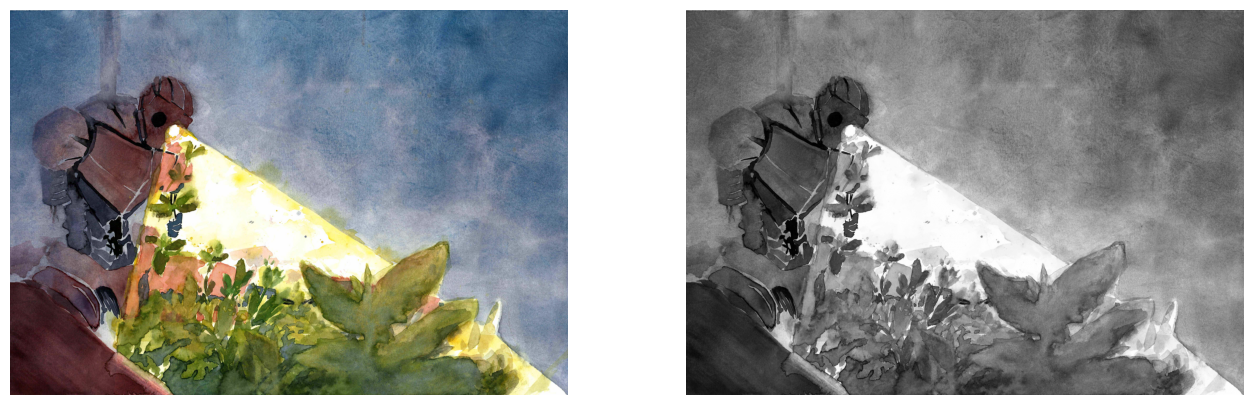

In [15]:
# Inspect Bram's artwork and its layers

image_name = "roboman"
extension = "png"
image_path = f"../input/bw26/{image_name}.{extension}"

img = Image.open(image_path)

fig, axs = plt.subplots(1,2,figsize=(16, 5))

axs[0].imshow(img)
axs[1].imshow(img.convert('L'), cmap='gray')
for ax in axs: ax.axis('off')

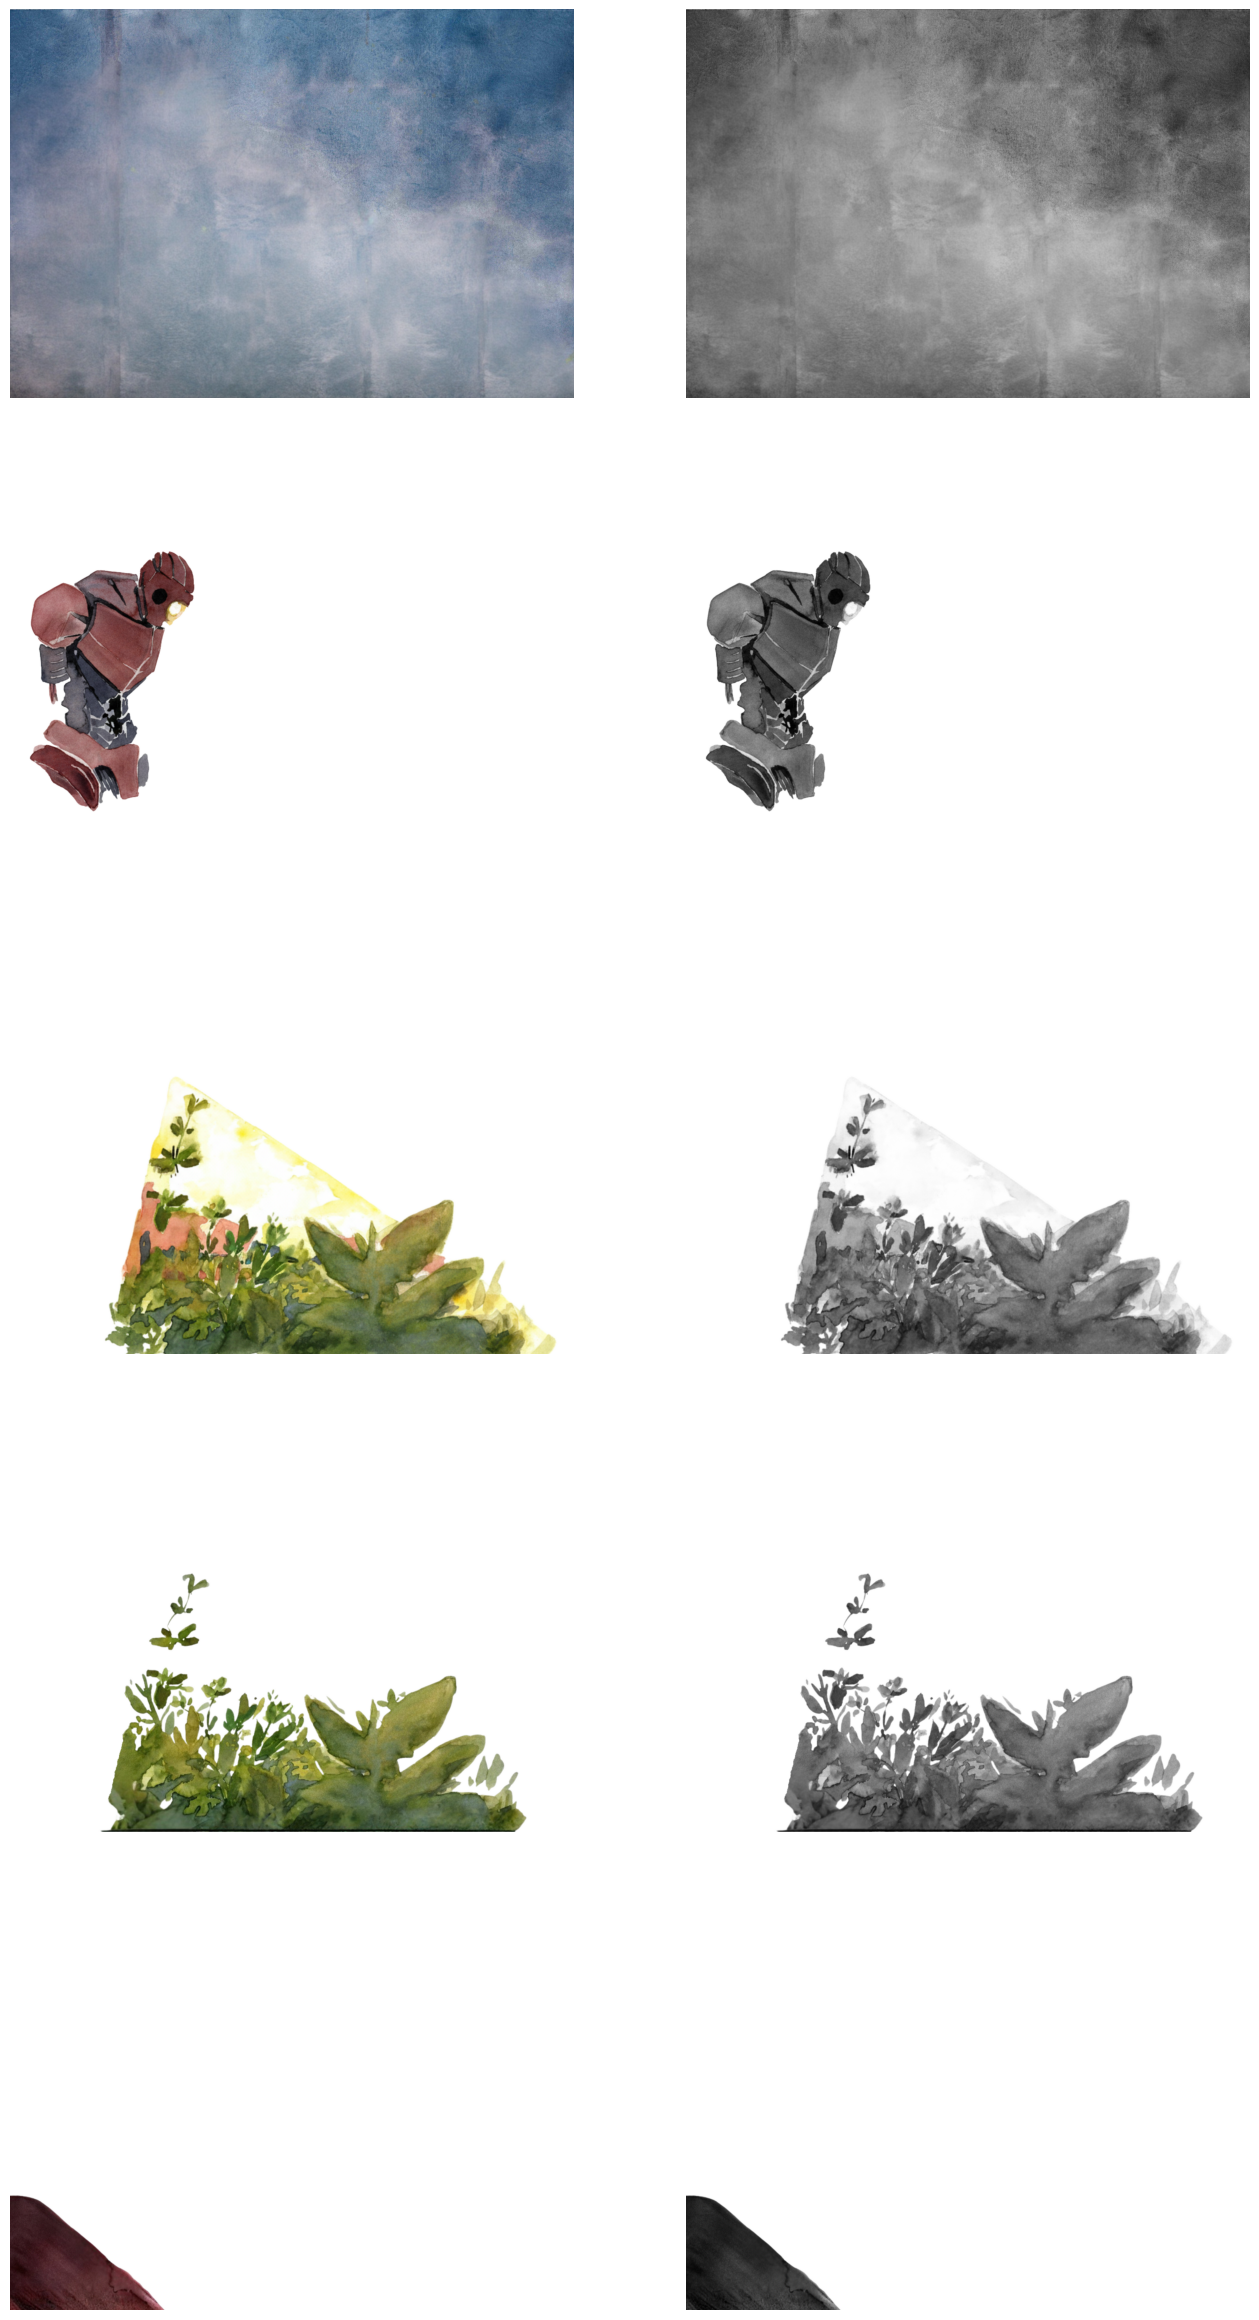

In [56]:
image_name = "roboman"
image_suffixes = ["background", "robot", "lightcone", "plants", "hill"]
extension = "png"

fig, axs = plt.subplots(5,2,figsize=(16, 6*5))

for ax_row, suffix in zip(axs, image_suffixes):
    image_name_full = f"{image_name}-{suffix}"
    image_path = f"../input/bw26/{image_name_full}.{extension}"
    img = Image.open(image_path)
    
    ax_row[0].imshow(img)
    ax_row[1].imshow(img.convert('L'), cmap='gray')
    for ax in ax_row: ax.axis('off')

In [38]:
# All Canva colour suggestions

background_colors = ['#909aaa', '#7e8898', '#a5acb9', '#6c7f99', '#4a6786']
robot_colors = ['#713c3c', '#996766', '#5e5962', '#221d21', '#c3b7b0']
lightcone_colors = ['#ece495', '#f1e6bb', '#f9f7e3', '#dfbf77']
plants_colors = ['#626e2b', '#485932', '#939546', '#727e52', '#1d2815']
hill_colors = ['#39191d', '#582e30', '#6b3031', '#4f1819', '#8f4c51']

# Selection of colours

background_color = background_colors[4]
robot_color = robot_colors[0]
lightcone_color = lightcone_colors[3]
plant_color = plants_colors[1]
hill_color = hill_colors[0]

# Concatenate all selected colours

colors = [background_color, robot_color, lightcone_color, plant_color, hill_color]

In [68]:
# Select mosaic dimensions

grid_size=150
level=4
invert=True
random=True
empty_tiles_cutoff=.99
horizontal_cropping = 0.0
bottom_cropping = 1.

SAVEARRAY = True

# Load the image and convert it to a still life mosaic
solution_mosaic_list = []
for suffix in image_suffixes:
    print(f"Working on image with suffix '{suffix}' ...             ", end='\r')
    # find right image
    image_name_full = f"{image_name}-{suffix}"
    image_path = f"../input/bw26/{image_name_full}.{extension}"
    solution_mosaic = mosaics.image_to_still_life(image_path,
                                                grid_size=grid_size,
                                                level=level,
                                                invert=invert,
                                                random=random,
                                                empty_tiles_cutoff=empty_tiles_cutoff)

    # crop horizontally
    if horizontal_cropping:
        crop_pixels = int(horizontal_cropping * solution_mosaic.shape[1] / 2)
        solution_mosaic = solution_mosaic[:, crop_pixels:-crop_pixels]

    # crop bottom
    if bottom_cropping<1:
        crop_pixels = int(bottom_cropping * solution_mosaic.shape[0])
        solution_mosaic = solution_mosaic[:-crop_pixels, :]

    if SAVEARRAY:
        np.save(f'../output/bw26/arrays/{image_name_full}-mosaic-level{level}-gridsize{grid_size}.npy',
                solution_mosaic)

    # add to list
    solution_mosaic_list.append(solution_mosaic)

mosaic_shape = solution_mosaic_list[0].shape
print("\nMosaic shape:", mosaic_shape)
print("Shape denominators:", mosaics.list_denominators(mosaic_shape[1]))

Working on image with suffix 'hill' ...                   
Mosaic shape: (1771, 2568)
Shape denominators: [1, 2, 3, 4, 6, 8, 12, 24, 107, 214, 321, 428, 642, 856, 1284, 2568]


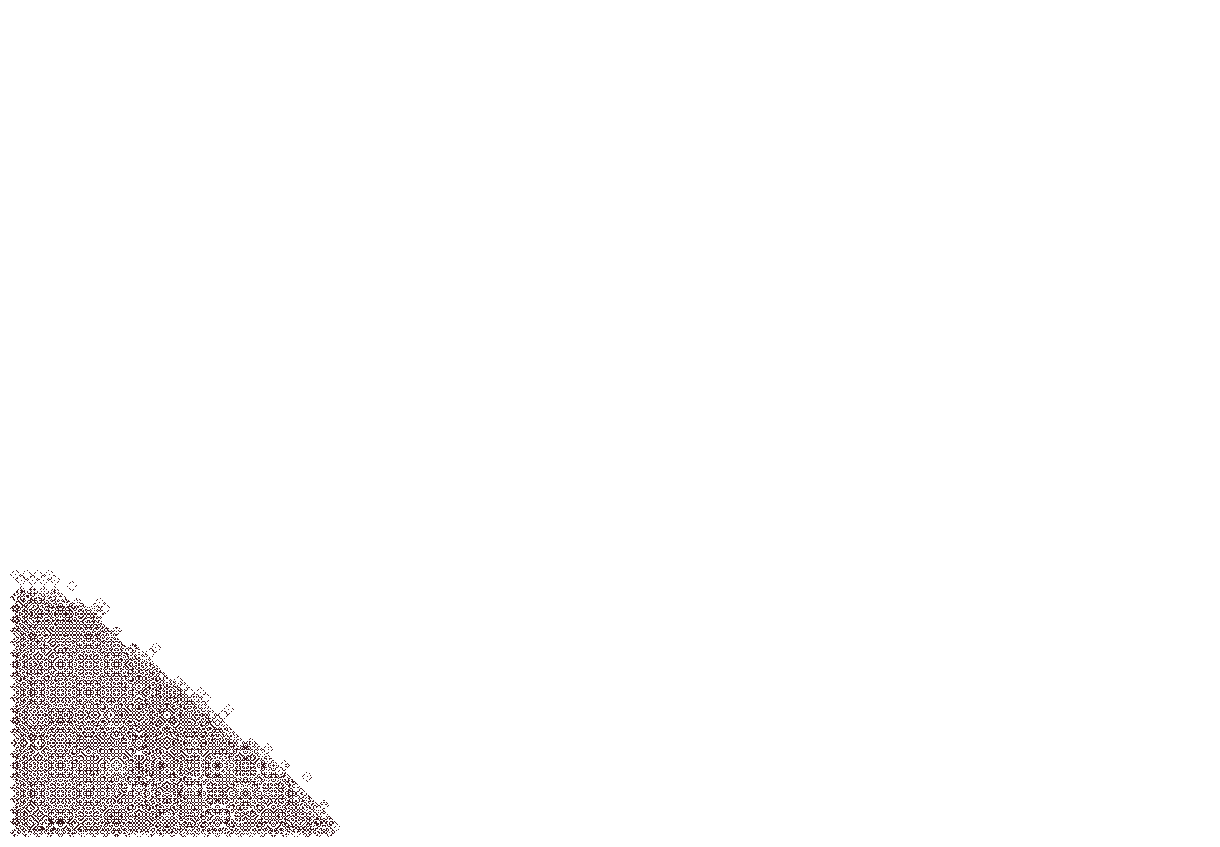

In [80]:
# Show and save results

INDEX = 4
SAVEFIG = True

fig, ax = plt.subplots(1, 1, figsize=(16, 6*5))

# IMPORTANT: pick a size that is a denominator of the mosaic shape
fig_size = 12
fig.set_size_inches(fig_size, fig_size)
ax.axis('off')

color = colors[INDEX]
suffix = image_suffixes[INDEX]
solution_mosaic = solution_mosaic_list[INDEX]
image_name_full = f"{image_name}-{suffix}"

# Create colormap with the selected colour
cmap_colors = ['none', color]
custom_cmap = LinearSegmentedColormap.from_list('custom', cmap_colors, N=2)

# show mosaic
ax.imshow(solution_mosaic, cmap=custom_cmap, interpolation='none')

# remove axes
ax.axis('off')
ax.axis('off')

# Remove padding
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

if SAVEFIG:
    dpi = solution_mosaic.shape[1] // fig_size
    plt.savefig(f'../output/bw26/images/{image_name_full}-mosaic-level{level}-gridsize{grid_size}.png',
                dpi=dpi, # 100 dpi × 10 inches = 1000 pixels
                bbox_inches='tight',
                pad_inches=0)
    # plt.close()